# cNMF

In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from matplotlib.colors import ListedColormap
from natsort import natsorted

from cnmf import cNMF
import warnings
warnings.filterwarnings("ignore")

/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/root/miniforge3/envs/scz_analysis/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Impor

In [2]:
# Set IO path
base_path = '/home/jiahao/wanglab/Data/Analyzed/2024-12-02-Mingrui-SCZ/'
expr_path = os.path.join(base_path, 'expr')
fig_path = os.path.join(base_path, 'figures')
output_path = os.path.join(base_path, 'output')
os.makedirs(output_path, exist_ok=True)
sc.settings.figdir = fig_path

In [4]:
# export as editable fonts
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

## Colors

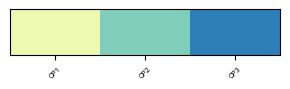

In [5]:
# CP1, CP2, CP3
cp_order = ['CP1', 'CP2', 'CP3']
cp_pl = sns.color_palette(['#edf8b1', '#7fcdbb', '#2c7fb8'])
cp_cmap = ListedColormap(cp_pl.as_hex())
sns.palplot(cp_pl)
plt.xticks(range(len(cp_order)), cp_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

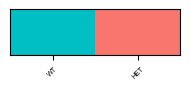

In [6]:
# WT, HET
condition_order = ['WT', 'HET']
condition_pl = sns.color_palette(['#00bfc4', '#f8766d'])
condition_cmap = ListedColormap(condition_pl.as_hex())
sns.palplot(condition_pl)
plt.xticks(range(len(condition_order)), condition_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

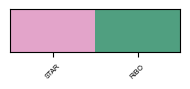

In [7]:
# STAR, RIBO
protocol_order = ['STAR', 'RIBO']
protocol_pl = sns.color_palette(['#e3a4ca', '#509f80'])
protocol_cmap = ListedColormap(protocol_pl.as_hex())
sns.palplot(protocol_pl)
plt.xticks(range(len(protocol_order)), protocol_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

## Input

In [8]:
# adata
adata = sc.read_h5ad(os.path.join(expr_path, '2025-05-12-finalized-ct-rgn.h5ad'))
adata

AnnData object with n_obs × n_vars = 538188 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label', 'ARG_score', 'OXFOS_score', 'Ribosome_score', 'ARG_score_region_delta', 'OXFOS_score_region_delta', 'Ribosome_score_region_delta'
    var: 'highly_variable', 'mean', 'std', 'max_counts'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'level_3_color_dict', 'level_3_colors', 'level_3

In [9]:
nmf_output_path = os.path.join(output_path, 'nmf')
os.makedirs(nmf_output_path, exist_ok=True)

## Save a count object

In [6]:
current_protocol = 'RIBO'
sdata = adata[adata.obs['protocol'] == current_protocol].copy()
sdata.X = sdata.layers['raw'].copy()
sdata.write_h5ad(os.path.join(nmf_output_path, 'RIBO_counts.h5ad'))

sdata.X = sdata.layers['norm1e4'].copy()
sdata.write_h5ad(os.path.join(nmf_output_path, 'RIBO_norm.h5ad'))

In [ ]:
tdata = sc.pp.subsample(sdata, fraction=0.25, random_state=0, copy=True)
tdata.write_h5ad(os.path.join(nmf_output_path, 'RIBO_counts_test.h5ad'))

tdata.X = tdata.layers['norm1e4'].copy()
tdata.write_h5ad(os.path.join(nmf_output_path, 'RIBO_norm_test.h5ad'))

In [6]:
tdata = sc.pp.subsample(adata, fraction=0.2, random_state=0, copy=True)
tdata.X = tdata.layers['raw'].copy()
tdata.write_h5ad(os.path.join(nmf_output_path, 'All_counts_test.h5ad'))

tdata.X = tdata.layers['norm1e4'].copy()
tdata.write_h5ad(os.path.join(nmf_output_path, 'All_norm_test.h5ad'))

In [7]:
adata.X = adata.layers['raw'].copy()
adata.write_h5ad(os.path.join(nmf_output_path, 'All_counts.h5ad'))

adata.X = adata.layers['norm1e4'].copy()
adata.write_h5ad(os.path.join(nmf_output_path, 'All_norm.h5ad'))

In [10]:
# current_output_path = os.path.join(nmf_output_path, 'l2_input')
# os.makedirs(current_output_path, exist_ok=True)

tdata = adata[adata.obs['level_2'] == 'PER']
tdata.X = tdata.layers['raw'].copy()
tdata.write_h5ad(os.path.join(nmf_output_path, 'per_counts.h5ad'))

tdata.X = tdata.layers['norm1e4'].copy()
tdata.write_h5ad(os.path.join(nmf_output_path, 'per_norm.h5ad'))

In [53]:
# write index to file
with open(os.path.join(nmf_output_path, 'genes.txt'), 'w') as f:
    for i in tdata.var_names:
        f.write(f"{i}\n")

## Create average expr

In [11]:
field = 'level_2'
expr = pd.DataFrame(sdata.layers['log2_norm1e4_scaled'].copy(),
                    index=sdata.obs.index,
                    columns=sdata.var.index)

expr[field] = sdata.obs[field].copy()
expr = expr.groupby(field).mean().T
expr.to_csv(os.path.join(nmf_output_path, f'{current_protocol}_{field}.csv'))

## cNMF

In [5]:
run_name = 'All_run'

numiter = 20
numhvgenes = 3447
k_range = np.arange(30, 40)
seed = 14
n_workers = 10

data_path = os.path.join(nmf_output_path, 'All_counts.h5ad')
norm_data_path = os.path.join(nmf_output_path, 'All_norm.h5ad')
gene_file_path = os.path.join(nmf_output_path, 'genes.txt')

In [6]:
## Initialize the cnmf object that will be used to run analyses
cnmf_obj = cNMF(output_dir=nmf_output_path, name=run_name)

In [8]:
## Prepare the data, I.e. subset to 2000 high-variance genes, and variance normalize
cnmf_obj.prepare(counts_fn=data_path, components=k_range, n_iter=numiter, seed=seed, 
                 tpm_fn=norm_data_path, genes_file=gene_file_path)

In [ ]:
cnmf_obj.factorize_multi_process(total_workers=n_workers, )

In [ ]:
cnmf_obj.update_nmf_iter_params()

In [ ]:
cnmf_obj.factorize(worker_i=0, total_workers=1, skip_completed_runs=True)

In [ ]:
cnmf_obj.combine()

### Evaluation

In [ ]:
cnmf_obj.k_selection_plot(close_fig=False)

In [19]:
selected_K = 35
density_threshold = 2.00

In [ ]:
cnmf_obj.consensus(k=selected_K, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)

In [ ]:
density_threshold = 0.2
cnmf_obj.consensus(k=selected_K, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)

In [ ]:
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=selected_K, density_threshold=density_threshold)
usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]

### Output

In [ ]:
selected_K = 35
density_threshold = 0.2
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=selected_K, density_threshold=density_threshold)
usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]

In [ ]:
for current_mod in topgenes.columns:
    if 'Arc' in topgenes[current_mod].values:
        print(f"Module {current_mod} contains Arc, Ranks: {np.argwhere(topgenes[current_mod].values == 'Arc')[0][0] + 1}")

In [32]:
current_output_path = os.path.join(nmf_output_path, run_name)
usage_norm.to_csv(os.path.join(current_output_path, f'{run_name}_usage_norm.csv'))
gep_scores.to_csv(os.path.join(current_output_path, f'{run_name}_gep_scores.csv'))
gep_tpm.to_csv(os.path.join(current_output_path, f'{run_name}_gep_tpm.csv'))
topgenes.to_csv(os.path.join(current_output_path, f'{run_name}_topgenes.csv'))

### Enrichr

In [6]:
import gseapy as gp
n_genes = 50
run_name = 'All_run'
current_output_path = os.path.join(nmf_output_path, run_name)

# load cNMF top genes 
top_genes = pd.read_csv(os.path.join(current_output_path, f'{run_name}_topgenes.csv'), index_col=0)
top_genes.columns = [f"M_{c}" for c in top_genes.columns]

top_genes_dict = top_genes.head(n_genes).to_dict(orient='list')

bg_list = adata.var_names.str.upper().tolist()

In [7]:
# # load custom gene list
# go_annot_df = pd.read_excel(os.path.join(base_path, 'documents', 'c5.all.v7.2.symbols.xlsx'), header=None)
# go_annot_df = go_annot_df.drop([1], axis=1)
# go_annot_df = go_annot_df.T
# go_annot_df.columns = go_annot_df.iloc[0]
# go_annot_df = go_annot_df.drop([0])

# GO_dict = {}
# for curruent_term in go_annot_df.columns:
#     GO_dict[curruent_term] = [gene for gene in go_annot_df[curruent_term].dropna()]

In [9]:
go_dbs = ['GO_Cellular_Component_2025', 'GO_Biological_Process_2025', 'GO_Molecular_Function_2025', 'SynGO_2024']

enrich_result_list = []
for module_id, module_genes in top_genes_dict.items():
    # print(module_id)
    res_obj = gp.enrichr(module_genes, gene_sets=go_dbs, organism='mouse', 
                       background=bg_list, outdir=None)
    # test = gp.enrich(module_genes, gene_sets=GO_dict, background=bg_list, outdir=None, verbose=True)
    current_result = res_obj.results.loc[res_obj.results['P-value'] < 0.05, :]
    current_result['module_id'] = module_id
    current_result['Term_size'] = current_result['Genes'].str.split(';').apply(len)
    enrich_result_list.append(current_result) 

enrich_result_df = pd.concat(enrich_result_list)
# enrich_result_df.to_csv(os.path.join(current_output_path, f'{run_name}_top{n_genes}_enrich_result.csv'), index=False)

In [386]:
enrich_result_filtered_df = enrich_result_df.loc[(enrich_result_df['Adjusted P-value'] < 0.05) & (enrich_result_df['Term_size'] > 2), :]
enrich_result_filtered_df.to_csv(os.path.join(current_output_path, f'{run_name}_top{n_genes}_enrich_result_filtered.csv'), index=False)

## Visualization

In [3]:
# reorder gene module based on level 2 cell type expr
module_name_dict = {
    '1': 'M25', # 
    '2': 'M1', # TEGLU
    '3': 'M24', # 
    '4': 'M26', # 
    '5': 'M13', # 
    '6': 'M27', # 
    '7': 'M28', # 
    '8': 'M29', # 
    '9': 'M14', # 
    '10': 'M30', # 
    '11': 'M12', # 
    '12': 'M10', # 
    '13': 'M7', # 
    '14': 'M4', # 
    '15': 'M9', # 
    '16': 'M31', # 
    '17': 'M32', # 
    '18': 'M20', # 
    '19': 'M6', # 
    '20': 'M33', # 
    '21': 'M15', # 
    '22': 'M2', # DGGRC
    '23': 'M8', # 
    '24': 'M3', # 
    '25': 'M17', # 
    '26': 'M22', # 
    '27': 'M16', # 
    '28': 'M21', #
    '29': 'M11', #
    '30': 'M19', #
    '31': 'M23', #
    '32': 'M34', #
    '33': 'M18', #
    '34': 'M35', #
    '35': 'M5', #
}

In [11]:
run_name = 'All_run'
n_genes = 50
current_output_path = os.path.join(nmf_output_path, run_name)

# load cNMF top genes 
top_genes = pd.read_csv(os.path.join(current_output_path, f'{run_name}_topgenes.csv'), index_col=0)
top_genes.columns = top_genes.columns.astype(str)
top_genes.columns = [module_name_dict[c] for c in top_genes.columns]
top_genes = top_genes.loc[:, natsorted(top_genes.columns)]
top_genes_dict = top_genes.head(n_genes).to_dict(orient='list')

In [12]:
# get all unique values in top_genes_dict.values()
top_genes_list = list(set(gene for module_genes in top_genes_dict.values() for gene in module_genes))
sdata = adata[:, top_genes_list].copy()
sdata

AnnData object with n_obs × n_vars = 538188 × 1234
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label', 'ARG_score', 'OXFOS_score', 'Ribosome_score', 'ARG_score_region_delta', 'OXFOS_score_region_delta', 'Ribosome_score_region_delta'
    var: 'highly_variable', 'mean', 'std', 'max_counts'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'level_3_color_dict', 'level_3_colors', 'level_3

In [13]:
sdata.X = sdata.layers['raw'].copy()
sc.pp.normalize_total(sdata, target_sum=1e3)
sc.pp.log1p(sdata, base=2)
sdata.layers['log2_norm1e3'] = sdata.X.copy()

In [14]:
expr_df = pd.DataFrame(sdata.layers['log2_norm1e4_scaled'], columns=sdata.var_names, index=sdata.obs.index)
expr_df

,Tnfrsf25,S1pr1,Stx17,Phyhip,Htra1,Sv2b,Homer2,Adamts4,Cox6a2,Rps7,...,Kcng4,Hs6st2,Kcna6,Rasd1,Hoxb3,Traip,Penk,Oprk1,Cdkn1c,Itpka
unique_index,,,,,,,,,,,,,,,,,,,,,
sample8_Position688_1,-0.118767,-0.207167,-0.201393,-0.438906,-0.260953,-0.288597,-0.179534,-0.153531,-0.165891,-0.510469,...,-0.142157,-0.131157,-0.418511,-0.101990,-0.167065,-0.166831,-0.303932,-0.180991,-0.187671,-0.221854
sample8_Position688_2,-0.064620,-0.216292,-0.097527,-0.246410,-0.246285,-0.126140,-0.112391,-0.106364,-0.079940,-0.389470,...,-0.068075,-0.096797,-0.269002,-0.055600,-0.103496,-0.035132,-0.196451,-0.061767,-0.072167,-0.164241
sample8_Position688_3,-0.077746,-0.214080,-0.122707,-0.293076,-0.249841,-0.165524,-0.128668,-0.117798,-0.100777,-0.418803,...,-0.086034,-0.105127,-0.305247,-0.066846,-0.118907,-0.067059,3.508175,-0.090670,-0.100168,-0.178208
sample8_Position688_5,-0.090052,-0.212006,-0.146313,-0.336825,-0.253175,-0.202446,-0.143928,-0.128518,-0.120311,-0.446303,...,-0.102871,-0.112936,-0.339226,-0.077389,-0.133354,-0.096991,-0.246935,-0.117766,-0.126419,-0.191301
sample8_Position688_6,-0.186040,-0.195829,-0.330438,-0.678067,-0.279176,-0.490438,-0.262953,-0.212133,-0.272678,-0.660800,...,-0.234197,-0.173847,2.067938,-0.159626,-0.246045,-0.330457,2.946587,-0.329118,-0.331177,-0.293433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample22_Position343_143,-0.194244,-0.194446,-0.346175,1.512073,-0.281398,-0.515052,-0.273126,-0.219280,-0.285701,-0.679133,...,-0.245421,-0.179053,-0.626918,-0.166655,-0.255677,-0.350412,-0.453753,-0.347182,-0.348677,-0.302162
sample22_Position343_144,-0.061748,-0.216776,-0.092019,-0.236202,-0.245508,-0.117525,-0.108831,-0.103862,-0.075382,2.425983,...,-0.064147,-0.094975,-0.261074,-0.053140,-0.100125,-0.028148,-0.190752,-0.055444,-0.066041,-0.161186
sample22_Position343_145,-0.159377,4.714143,-0.279292,1.788212,-0.271953,-0.410440,-0.229891,-0.188907,-0.230354,-0.601218,...,-0.197718,-0.156927,-0.530643,-0.136782,-0.214742,-0.265606,-0.384542,-0.270409,-0.274299,-0.265063


In [15]:
expr_df['level_2'] = sdata.obs['level_2']
expr_mean_df = expr_df.groupby('level_2').mean()
expr_mean_df

,Tnfrsf25,S1pr1,Stx17,Phyhip,Htra1,Sv2b,Homer2,Adamts4,Cox6a2,Rps7,...,Kcng4,Hs6st2,Kcna6,Rasd1,Hoxb3,Traip,Penk,Oprk1,Cdkn1c,Itpka
level_2,,,,,,,,,,,,,,,,,,,,,
TEGLU,-0.001308,-0.101273,-0.029601,0.185674,-0.146167,0.225919,-0.002756,-0.010775,-0.090173,0.056555,...,-0.032365,-0.003862,-0.026767,-0.021916,0.008639,-0.049129,-0.188835,-0.039709,0.052590,0.156298
DGGRC,0.014936,-0.160724,-0.007913,0.347535,-0.166856,-0.031753,-0.035089,-0.014414,-0.046044,0.139172,...,-0.026819,-0.036362,-0.124286,0.023359,0.019296,0.034629,-0.163764,-0.009438,-0.040247,0.166257
TEINH,0.080345,-0.090682,-0.018785,-0.125732,-0.116534,-0.165592,-0.011148,-0.024094,0.348646,0.065004,...,0.065869,0.045144,0.080225,-0.022931,-0.007822,-0.082245,-0.133266,0.004910,-0.081421,-0.083076
MSN,-0.014775,-0.110368,0.105249,0.395324,-0.155822,-0.084642,-0.040800,0.070144,-0.035909,-0.078298,...,-0.014232,0.048915,-0.266700,0.021484,-0.023164,0.289849,1.268251,0.031751,0.048278,0.096121
DEGLU,0.021042,-0.077833,-0.015720,-0.307378,-0.121074,-0.113311,0.049999,-0.013481,0.380260,0.021174,...,-0.058828,0.027821,0.129862,0.084325,0.093242,-0.086473,-0.204614,0.089895,-0.154515,-0.144237
PEP,0.000729,-0.130899,-0.006859,0.007575,-0.186337,-0.065176,0.011633,-0.017073,0.030798,0.185136,...,-0.011856,0.146372,0.039648,-0.009403,0.011568,0.011160,0.022905,-0.002164,-0.070887,-0.005776
HABCHO,-0.007034,-0.121894,-0.022637,-0.066185,-0.161741,0.052633,0.023856,-0.015317,-0.056230,0.092020,...,0.236261,0.052845,-0.086909,0.019582,-0.005787,0.016788,-0.150899,0.017927,-0.013661,-0.020743
AC,-0.006480,0.547703,-0.020904,-0.174980,0.943167,-0.098521,-0.025538,-0.048766,-0.038632,-0.074285,...,0.006297,-0.049061,-0.107576,-0.018518,-0.063714,-0.010141,-0.125871,-0.027970,-0.038287,-0.102403
OLG,-0.020724,-0.113523,0.015553,-0.212006,-0.009087,-0.106157,-0.038693,0.107168,-0.038113,-0.049586,...,-0.007681,-0.032888,0.489036,0.000720,-0.025825,-0.013506,-0.101517,0.009011,-0.032276,-0.113644


In [16]:
# index expr_mean_df with top_genes_dict
plot_df_list = []
for module_id, module_genes in top_genes_dict.items():
    plot_df = expr_mean_df.loc[:, module_genes].T
    # plot_df['module_id'] = module_id
    plot_df_list.append(plot_df)

plot_df = pd.concat(plot_df_list)
plot_df

level_2,TEGLU,DGGRC,TEINH,MSN,DEGLU,PEP,HABCHO,AC,OLG,OPC,MGL,CHOR,PER,VEN,VLM,VSM,Mix
Atp1a1,0.323730,0.313996,-0.106057,-0.091610,-0.263316,-0.032950,0.053936,-0.224925,-0.088655,-0.035903,-0.111707,0.202026,-0.167430,-0.175675,-0.150597,-0.037475,0.086734
Rtn4r,0.259220,0.232605,-0.137855,-0.196562,0.015682,-0.097608,0.102675,-0.113443,-0.139018,-0.044048,-0.055539,-0.009045,-0.102688,-0.089577,-0.114320,-0.021092,0.136065
Bsn,0.246354,0.024915,0.090651,-0.024076,0.054796,-0.032963,0.015232,-0.133938,-0.249645,-0.036412,-0.086838,-0.108650,-0.139978,-0.121694,-0.249105,-0.113913,0.148225
Chn1,0.440778,0.751087,-0.056290,0.387321,-0.448853,-0.111505,-0.120151,-0.317464,-0.456196,-0.123761,-0.124175,-0.118694,-0.251437,-0.158056,-0.519728,-0.196750,0.264522
Rbfox3,0.320878,0.312834,-0.040566,0.276722,-0.281879,-0.043530,0.034226,-0.239598,-0.329160,-0.114416,-0.106544,-0.064500,-0.196714,-0.163307,-0.355476,-0.156109,0.228904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Arl4d,-0.037930,-0.043927,0.030219,-0.009973,-0.023366,-0.019626,-0.025932,-0.006517,0.134595,-0.046267,-0.061991,-0.001122,0.008115,-0.047201,0.023377,0.000836,-0.012883
Iqgap1,-0.050237,-0.043877,-0.034404,-0.034387,0.021067,-0.039162,-0.018615,-0.015581,-0.032999,-0.018533,-0.033940,0.044399,0.213590,0.134107,0.177509,0.218037,-0.027486
Pltp,-0.149644,-0.185022,-0.118653,-0.130404,-0.038036,-0.149824,-0.130610,-0.138025,-0.143426,-0.143126,-0.108122,0.250612,1.493303,0.295799,0.215879,0.275932,-0.133843
Dusp4,0.002323,0.036586,0.024641,-0.041634,0.120636,-0.004988,0.011905,-0.014026,-0.057363,0.006450,-0.039894,0.012657,0.056107,0.002219,-0.000861,0.033531,0.016512


### Average LogFC

In [17]:
expr_df = pd.DataFrame(sdata.layers['log2_norm1e3'].toarray(), columns=sdata.var_names, index=sdata.obs.index)
expr_df['sample_id'] = sdata.obs['sample_id'].values
expr_df

,Tnfrsf25,S1pr1,Stx17,Phyhip,Htra1,Sv2b,Homer2,Adamts4,Cox6a2,Rps7,...,Hs6st2,Kcna6,Rasd1,Hoxb3,Traip,Penk,Oprk1,Cdkn1c,Itpka,sample_id
unique_index,,,,,,,,,,,,,,,,,,,,,
sample8_Position688_1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,sample8
sample8_Position688_2,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,sample8
sample8_Position688_3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,3.841302,0.0,0.0,0.0,sample8
sample8_Position688_5,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,sample8
sample8_Position688_6,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,3.175066,0.0,0.0,0.0,3.175066,0.0,0.0,0.0,sample8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample22_Position343_143,0.0,0.000000,0.0,2.172735,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,sample22
sample22_Position343_144,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,4.477457,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,sample22
sample22_Position343_145,0.0,3.317392,0.0,2.455309,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,sample22


In [18]:
test_df = expr_df.groupby('sample_id').mean(numeric_only=True)
tdata = ad.AnnData(test_df)

sample_annot_df = pd.DataFrame(index=natsorted(adata.obs['sample_id'].unique()))
sample_annot_df['protocol'] = sample_annot_df.index.map(adata.obs.set_index('sample_id')['protocol'].to_dict())
sample_annot_df['condition'] = sample_annot_df.index.map(adata.obs.set_index('sample_id')['condition'].to_dict())
sample_annot_df['replicate'] = sample_annot_df.index.map(adata.obs.set_index('sample_id')['replicate'].to_dict())
sample_annot_df['coronal_position'] = sample_annot_df.index.map(adata.obs.set_index('sample_id')['coronal_position'].to_dict())
tdata.obs = pd.merge(left=tdata.obs, right=sample_annot_df, how='left', left_index=True, right_index=True)
tdata

AnnData object with n_obs × n_vars = 24 × 1234
    obs: 'protocol', 'condition', 'replicate', 'coronal_position'

In [19]:
# average logfc of top 50 genes in each module
module_logfc_dict = {
    'STAR': [],
    'RIBO': [],
}
for protocol in ['STAR', 'RIBO']:
    gdata = tdata[tdata.obs['protocol'].isin([protocol])]
    sc.tl.rank_genes_groups(gdata, groupby='condition', method='wilcoxon')
    df = sc.get.rank_genes_groups_df(gdata, group='HET')
    for i, (module_id, module_genes) in enumerate(top_genes_dict.items()):
        current_df = df.loc[df['names'].isin(module_genes), ['names', 'logfoldchanges']]
        average_logfc = current_df['logfoldchanges'].mean()
        module_logfc_dict[protocol].append(average_logfc)

ave_logfc_df = pd.DataFrame(module_logfc_dict, index=top_genes_dict.keys())
ave_logfc_df

,STAR,RIBO
M1,-0.155411,-0.169778
M2,-0.047219,-0.291642
M3,-0.052864,-0.109783
M4,-0.018128,-0.280835
M5,-0.142373,-0.143271
M6,-0.015031,-0.212239
M7,-0.115652,-0.321592
M8,-0.038820,-0.107685
M9,-0.084608,-0.073248
M10,-0.089033,-0.108930


In [20]:
test_df = expr_df.groupby('sample_id').mean(numeric_only=True)
sm_df = pd.DataFrame(index=natsorted(adata.obs['sample_id'].unique()))
for module_id, module_genes in top_genes_dict.items():
    current_df = test_df.loc[:, module_genes]
    current_df = current_df.sum(axis=1)
    sm_df[module_id] = current_df

mdata = ad.AnnData(sm_df)

sample_annot_df = pd.DataFrame(index=natsorted(adata.obs['sample_id'].unique()))
sample_annot_df['protocol'] = sample_annot_df.index.map(adata.obs.set_index('sample_id')['protocol'].to_dict())
sample_annot_df['condition'] = sample_annot_df.index.map(adata.obs.set_index('sample_id')['condition'].to_dict())
sample_annot_df['replicate'] = sample_annot_df.index.map(adata.obs.set_index('sample_id')['replicate'].to_dict())
sample_annot_df['coronal_position'] = sample_annot_df.index.map(adata.obs.set_index('sample_id')['coronal_position'].to_dict())
mdata.obs = pd.merge(left=mdata.obs, right=sample_annot_df, how='left', left_index=True, right_index=True)
sm_df = pd.merge(left=sm_df, right=sample_annot_df, how='left', left_index=True, right_index=True)
sm_df

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M30,M31,M32,M33,M34,M35,protocol,condition,replicate,coronal_position
sample1,40.653007,15.653321,25.325361,11.042729,9.143864,10.668805,23.154696,15.884809,25.631164,29.903976,...,9.244863,22.274682,18.242650,13.073033,6.286167,13.409497,RIBO,WT,rep1,PFC
sample2,26.016957,26.936126,25.191737,30.349760,9.424993,23.704794,14.577501,26.411877,17.527207,19.718491,...,28.586891,37.176047,28.012492,26.163255,9.801910,15.179700,STAR,WT,rep1,PFC
sample3,39.152043,15.062421,25.305864,10.379462,9.390394,9.918333,21.542166,14.072796,25.611236,30.313626,...,9.895056,21.920756,17.270192,10.674077,6.544590,12.226321,RIBO,HET,rep1,PFC
sample4,24.996586,26.585829,25.081317,29.853382,9.062818,23.118348,13.700726,25.104964,17.016339,19.479217,...,28.330466,36.989233,27.873461,26.346739,9.287798,13.371504,STAR,HET,rep1,PFC
sample5,35.206906,13.542805,22.707059,9.075944,8.636955,14.654872,28.279672,14.945879,23.099198,25.130325,...,8.772484,20.083432,14.381556,11.308076,9.003544,12.807656,RIBO,WT,rep1,ST
sample6,23.891379,22.942135,22.573337,25.620075,8.288404,30.621022,18.618089,22.973320,16.222001,17.197322,...,25.048512,33.601996,22.123901,27.395522,11.190804,12.664911,STAR,WT,rep1,ST
sample7,29.369994,11.486171,19.859504,7.628179,7.569785,11.764660,22.595346,12.289568,20.196610,22.150835,...,7.870550,16.616683,12.186789,8.138573,8.168318,9.931777,RIBO,HET,rep1,ST
sample8,23.686211,23.910689,22.771921,26.259789,8.056111,32.795966,18.645154,22.896779,15.987434,16.677283,...,27.275284,35.897750,22.332521,24.812057,11.989095,11.407399,STAR,HET,rep1,ST
sample9,20.754305,10.666149,22.428814,9.378212,7.168618,7.452767,13.977304,15.829034,26.265420,25.910073,...,5.761980,11.371116,11.256645,13.422414,4.473595,9.717590,RIBO,WT,rep1,HP
sample10,14.269584,19.750659,21.686814,27.018560,7.549297,16.701973,10.284293,26.880460,16.575737,16.661855,...,17.389481,22.051814,17.702792,30.711308,6.849824,11.121396,STAR,WT,rep1,HP


In [21]:
# average logfc of top 50 genes in each module
module_logfc_dict = {
    'STAR': [],
    'STAR_p': [],
    'RIBO': [],
    'RIBO_p': [],
}
for protocol in ['STAR', 'RIBO']:
    gdata = mdata[mdata.obs['protocol'].isin([protocol])]
    sc.tl.rank_genes_groups(gdata, groupby='condition', method='wilcoxon')
    df = sc.get.rank_genes_groups_df(gdata, group='HET')
    df.index = df.names
    df = df.loc[natsorted(df.names)]
    module_logfc_dict[f'{protocol}_p'] = df['pvals'].values
    module_logfc_dict[f'{protocol}'] = df['logfoldchanges'].values
ave_logfc_df = pd.DataFrame(module_logfc_dict, index=top_genes_dict.keys())
ave_logfc_df

,STAR,STAR_p,RIBO,RIBO_p
M1,-1.246563,0.521839,-3.610212,0.423340
M2,-0.232657,1.000000,-2.239401,0.336668
M3,-0.291672,0.630954,-1.638555,0.630954
M4,-0.069856,1.000000,-1.630108,0.200185
M5,-0.426176,0.423340,-0.388453,0.630954
M6,-0.157818,1.000000,-2.586488,0.262332
M7,-0.351095,0.748774,-4.002021,0.423340
M8,-0.062564,1.000000,-1.948532,0.078169
M9,-0.260585,0.872780,-1.108575,0.748774
M10,-0.537714,0.630954,-1.493199,0.630954


In [22]:
# average logfc of top 50 genes in each module
module_logfc_dict = {
    'STAR': [],
    'RIBO': [],
}
for protocol in ['STAR', 'RIBO']:
    temp_df = sm_df.loc[sm_df['protocol'] == protocol]
    temp_ave = temp_df.groupby('condition').mean(numeric_only=True).T
    temp_logfc = temp_ave['HET'] - temp_ave['WT']
    module_logfc_dict[protocol] = temp_logfc

ave_logfc_df = pd.DataFrame(module_logfc_dict, index=top_genes_dict.keys())
ave_logfc_df

,STAR,RIBO
M1,-0.864052,-2.502408
M2,-0.161265,-1.552232
M3,-0.202172,-1.135759
M4,-0.048420,-1.129840
M5,-0.295273,-0.269186
M6,-0.109391,-1.792782
M7,-0.243360,-2.773990
M8,-0.043366,-1.350619
M9,-0.180624,-0.768406
M10,-0.372715,-1.035007


In [23]:
# average expression of top 50 genes in each module
sm_df = pd.DataFrame()
for module_id, module_genes in top_genes_dict.items():
    current_df = expr_df.loc[:, module_genes]
    current_df = current_df.sum(axis=1)
    sm_df[module_id] = current_df

mdata = ad.AnnData(sm_df)
mdata.obs = adata.obs.copy()

module_logfc_dict = {
    'STAR': [],
    'STAR_p': [],
    'RIBO': [],
    'RIBO_p': [],
}
for protocol in ['STAR', 'RIBO']:
    gdata = mdata[mdata.obs['protocol'].isin([protocol])]
    sc.tl.rank_genes_groups(gdata, groupby='condition', method='wilcoxon')
    df = sc.get.rank_genes_groups_df(gdata, group='HET')
    df.index = df.names
    df = df.loc[natsorted(df.names)]
    module_logfc_dict[f'{protocol}_p'] = df['pvals'].values
    module_logfc_dict[f'{protocol}'] = df['logfoldchanges'].values
ave_logfc_df = pd.DataFrame(module_logfc_dict, index=top_genes_dict.keys())
ave_logfc_df

,STAR,STAR_p,RIBO,RIBO_p
M1,-1.136346,4.904042e-63,-3.447503,7.206491e-153
M2,0.002192,6.796723e-01,-2.108580,3.174895e-237
M3,-0.235979,1.486472e-05,-1.611241,6.407193e-94
M4,0.351337,1.207875e-01,-1.559928,1.137376e-228
M5,-0.433781,6.864131e-50,-0.419330,8.201995e-20
M6,-0.010179,3.289532e-04,-2.617342,0.000000e+00
M7,-0.284968,9.438404e-09,-4.104760,0.000000e+00
M8,-0.016428,4.122253e-04,-2.025916,4.051483e-265
M9,-0.339367,5.549215e-17,-1.190104,4.514109e-55
M10,-0.507441,3.375723e-29,-1.469656,5.830345e-55


### DEG counts

In [86]:
deg_file_path = os.path.join(base_path, 'expr/DE analysis/nmf', '2025-06-18_level_2_nmf_filtered_DEG.xlsx')
star_deg_dict = {current_ctype: pd.read_excel(deg_file_path, sheet_name=f'{current_ctype}_STAR') for current_ctype in adata.obs['level_2'].cat.categories}
ribo_deg_dict = {current_ctype: pd.read_excel(deg_file_path, sheet_name=f'{current_ctype}_RIBO') for current_ctype in adata.obs['level_2'].cat.categories}

In [74]:
deg_counts_dict = {}
for current_ctype in adata.obs['level_2'].cat.categories:
    current_star_df = star_deg_dict[current_ctype]
    current_star_up = current_star_df.loc[current_star_df['logfoldchanges'] > 0].shape[0]
    current_star_down = -current_star_df.loc[current_star_df['logfoldchanges'] < 0].shape[0]
    current_ribo_df = ribo_deg_dict[current_ctype]
    current_ribo_up = current_ribo_df.loc[current_ribo_df['logfoldchanges'] > 0].shape[0]
    current_ribo_down = -current_ribo_df.loc[current_ribo_df['logfoldchanges'] < 0].shape[0]
    deg_counts_dict[current_ctype] = [current_star_up, current_star_down, current_ribo_up, current_ribo_down]

In [75]:
deg_counts_df = pd.DataFrame(deg_counts_dict)
deg_counts_df

,TEGLU,DGGRC,TEINH,MSN,DEGLU,PEP,HABCHO,AC,OLG,OPC,MGL,CHOR,PER,VEN,VLM,VSM,Mix
0,103,5,40,69,23,0,10,20,33,2,7,12,34,17,12,17,44
1,-22,-1,-2,-135,-36,-2,-15,-37,-77,-1,-8,-10,-18,-5,-2,-2,-8
2,34,2,14,1,14,1,0,3,4,1,1,7,15,6,5,4,12
3,-446,-5,-106,-304,-62,-10,-8,-61,-52,-6,-19,-12,-24,-11,-7,-6,-59


### Heatmap

In [76]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

In [26]:
plot_df = plot_df.T
plot_df

,Atp1a1,Rtn4r,Bsn,Chn1,Rbfox3,Stx1a,Sv2b,Itpka,Olfm2,Kcnv1,...,Klf7,Scg2,Dnajb1,Tmem64,Ier2,Arl4d,Iqgap1,Pltp,Dusp4,Etv3
level_2,,,,,,,,,,,,,,,,,,,,,
TEGLU,0.323730,0.259220,0.246354,0.440778,0.320878,0.267353,0.225919,0.156298,0.247223,0.116787,...,-0.013681,-0.007825,0.023965,0.072526,0.021622,-0.037930,-0.050237,-0.149644,0.002323,0.001972
DGGRC,0.313996,0.232605,0.024915,0.751087,0.312834,-0.031221,-0.031753,0.166257,-0.138194,-0.012765,...,-0.027788,0.236869,-0.006989,0.018213,-0.005110,-0.043927,-0.043877,-0.185022,0.036586,0.047256
TEINH,-0.106057,-0.137855,0.090651,-0.056290,-0.040566,0.007494,-0.165592,-0.083076,0.109126,-0.057998,...,-0.057246,0.380932,0.075464,-0.047328,0.030704,0.030219,-0.034404,-0.118653,0.024641,0.007887
MSN,-0.091610,-0.196562,-0.024076,0.387321,0.276722,-0.156524,-0.084642,0.096121,-0.214943,-0.001873,...,-0.043471,0.107685,-0.011031,-0.082261,0.020840,-0.009973,-0.034387,-0.130404,-0.041634,0.068456
DEGLU,-0.263316,0.015682,0.054796,-0.448853,-0.281879,-0.093662,-0.113311,-0.144237,-0.217194,-0.108428,...,0.006440,0.137595,0.151864,-0.157789,0.024229,-0.023366,0.021067,-0.038036,0.120636,-0.062040
PEP,-0.032950,-0.097608,-0.032963,-0.111505,-0.043530,0.072875,-0.065176,-0.005776,0.100402,-0.043375,...,-0.031299,0.601724,0.123982,0.016477,0.020435,-0.019626,-0.039162,-0.149824,-0.004988,0.025078
HABCHO,0.053936,0.102675,0.015232,-0.120151,0.034226,0.024656,0.052633,-0.020743,0.181440,-0.017273,...,0.014089,0.152279,0.032917,0.053492,-0.013569,-0.025932,-0.018615,-0.130610,0.011905,-0.004795
AC,-0.224925,-0.113443,-0.133938,-0.317464,-0.239598,-0.108017,-0.098521,-0.102403,-0.114156,-0.061773,...,0.003198,-0.146722,-0.073536,-0.080814,-0.032104,-0.006517,-0.015581,-0.138025,-0.014026,-0.046230
OLG,-0.088655,-0.139018,-0.249645,-0.456196,-0.329160,-0.167456,-0.106157,-0.113644,-0.132750,-0.054738,...,0.032150,-0.162038,-0.062922,-0.127876,-0.045125,0.134595,-0.032999,-0.143426,-0.057363,-0.020817


In [28]:
ave_logfc_df = ave_logfc_df.T
ave_logfc_df

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M26,M27,M28,M29,M30,M31,M32,M33,M34,M35
STAR,-0.155411,-0.047219,-0.052864,-0.018128,-0.142373,-0.015031,-0.115652,-0.038820,-0.084608,-0.089033,...,0.068351,-0.019795,-0.167783,0.052341,-0.080839,-0.029077,-0.035282,0.010182,-0.07614,-0.027513
RIBO,-0.169778,-0.291642,-0.109783,-0.280835,-0.143271,-0.212239,-0.321592,-0.107685,-0.073248,-0.108930,...,-0.208872,-0.344052,-0.974142,-0.404850,-0.085967,-0.193026,-0.137379,-0.342873,0.03936,0.085359


In [30]:
deg_counts_df = deg_counts_df.T
deg_counts_df

,0,1,2,3
TEGLU,103,-22,34,-446
DGGRC,5,-1,2,-5
TEINH,40,-2,14,-106
MSN,69,-135,1,-304
DEGLU,23,-36,14,-62
PEP,0,-2,1,-10
HABCHO,10,-15,0,-8
AC,20,-37,3,-61
OLG,33,-77,4,-52
OPC,2,-1,1,-6


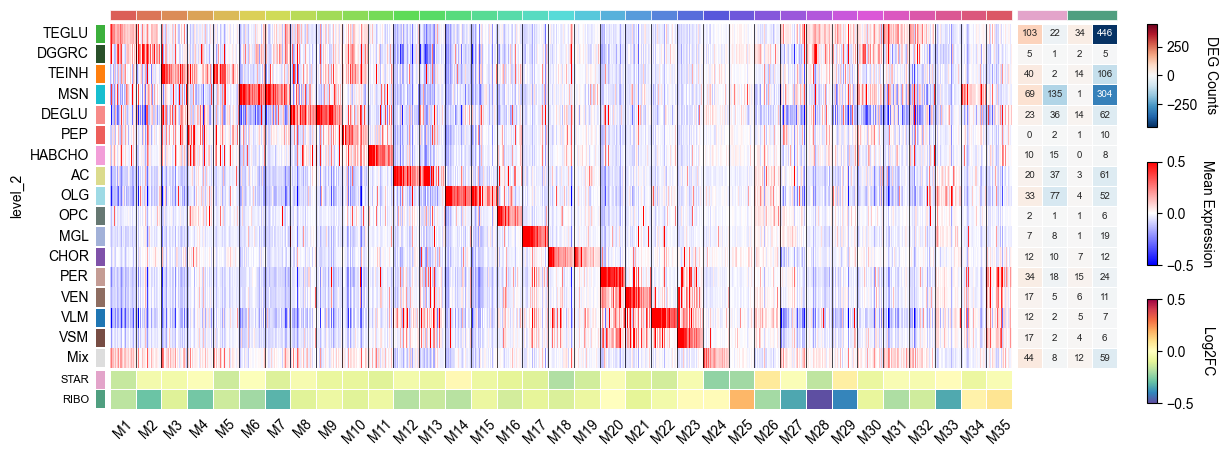

In [78]:
from matplotlib.gridspec import GridSpec

# Figure & axes
fig = plt.figure(figsize=(13, 5))      
gs  = GridSpec(
        nrows=2, ncols=2,
        height_ratios=[.9, .1],       
        width_ratios =[.9, .1],
        hspace=0.01, wspace=0.01)

ax_main = fig.add_subplot(gs[0, 0])    
ax_logfc = fig.add_subplot(gs[1, 0])    
ax_deg_counts = fig.add_subplot(gs[0, 1]) 

# turn the unused top-right cell off
fig.add_subplot(gs[1, 1]).axis('off')
    
# Expression heat-map
sns.heatmap(plot_df, cmap='bwr', vmin=-0.5, vmax=0.5, ax=ax_main, cbar=False,
                 cbar_kws={'label': 'Expression Z-score', 'shrink': 0.25, 'location': 'right'})

ax_main.set_xticks([])               
ax_main.set_xlabel('')

# row colors 
ax_main.set_yticks([i + 0.5 for i in range(len(plot_df.index))])
ax_main.tick_params(axis='y', which='major', pad=15, length=0) 
ax_main.set_yticklabels(plot_df.index, rotation=0)
for i, color in enumerate(sdata.uns['level_2_colors']):
    ax_main.add_patch(plt.Rectangle(xy=(-0.015, i+0.05), width=.01, height=.9, color=color, lw=0,
                               transform=ax_main.get_yaxis_transform(), clip_on=False))


# col colors 
ax_main.tick_params(axis='x', which='major', pad=35, length=0) 
# Create y-tick positions and labels for gene modules
x_tick_positions = []
x_tick_labels = []
current_pos = 0

for module_id, module_genes in top_genes_dict.items():
    # Add tick at the middle of each module
    module_size = len(module_genes)
    x_tick_positions.append(current_pos + module_size / 2)
    x_tick_labels.append(module_id)
    current_pos += module_size

ax_main.set_xticks(x_tick_positions)
ax_main.set_xticklabels(x_tick_labels, rotation=45)

for i, color in enumerate(sns.color_palette('hls', n_colors=len(top_genes_dict))):
    ax_main.add_patch(plt.Rectangle(xy=(50*i, 1.01), width=50, height=.03, color=color, # lw=0,
                                    lw=0.5, ec='white', linestyle='-',
                               transform=ax_main.get_xaxis_transform(), clip_on=False))
    
# Add vertical lines to separate gene modules
current_pos = 0
for i, (module_id, module_genes) in enumerate(top_genes_dict.items()):
    if i > 0:  # Don't add line before first module
        ax_main.axvline(x=current_pos, color='black', linewidth=.5, alpha=1)
    current_pos += len(module_genes)

# LogFC heat-map
sns.heatmap(ave_logfc_df, cmap='Spectral_r', vmin=-0.5, vmax=0.5, 
                  cbar=False, linewidth=.5, linecolor='white',
                  ax=ax_logfc)
# Remove y-axis ticks for the second plot
ax_logfc.set_xticks([])
ax_logfc.set_xticklabels([])

y_tick_positions = [.5, 1.5]
y_tick_labels = ['STAR', 'RIBO']

ax_logfc.set_yticks(y_tick_positions)
ax_logfc.set_yticklabels(y_tick_labels, rotation=0, fontsize=8)
ax_logfc.tick_params(axis='y', which='major', pad=15, length=0) 

# col colors 
for i, color in enumerate(['#e3a4ca', '#509f80']):
    ax_logfc.add_patch(plt.Rectangle(xy=(-0.015, i+0.05), width=.01, height=.9, color=color, lw=0,
                               transform=ax_logfc.get_yaxis_transform(), clip_on=False))

# DEG counts
annot_data = np.abs(deg_counts_df)
sns.heatmap(
    deg_counts_df,
    cmap='RdBu_r',            
    cbar=False,
    annot=annot_data,
    fmt='d',
    annot_kws={"size": 7},
    vmin=-450, vmax=450,
    linewidth=.5, linecolor='white',
    ax=ax_deg_counts)

ax_deg_counts.set_yticks([])               
ax_deg_counts.set_ylabel('')

# col colors 
ax_deg_counts.tick_params(axis='x', which='major', pad=15, length=0) 
# Create y-tick positions and labels for two protocols
x_tick_positions = [1, 3]
ax_deg_counts.set_xticks(x_tick_positions)

for i, color in enumerate(['#e3a4ca', '#509f80']):
    ax_deg_counts.add_patch(plt.Rectangle(xy=(i*2, 1.01), width=2, height=.03, color=color, 
                                          lw=0.5, ec='white', linestyle='-',
                               transform=ax_deg_counts.get_xaxis_transform(), clip_on=False))


# Add colorbars for both subplots with proper positioning to avoid overlap
cax = ax_main.inset_axes([1.15, .7, 0.01, 0.3])
cbar1 = plt.colorbar(ax_deg_counts.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar1.set_label('DEG Counts', rotation=270, labelpad=15)

cax = ax_main.inset_axes([1.15, .3, 0.01, 0.3])
cbar2 = plt.colorbar(ax_main.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar2.set_label('Mean Expression', rotation=270, labelpad=15)

cax = ax_main.inset_axes([1.15, -0.1, 0.01, 0.3])
cbar3 = plt.colorbar(ax_logfc.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar3.set_label('Log2FC', rotation=270, labelpad=15)

# plt.subplots_adjust(wspace=0.05) 
# plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'cNMF_heatmap_horizontal.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### Enrichr

In [135]:
enrich_result_df = pd.read_csv(os.path.join(current_output_path, f'{run_name}_top50_enrich_result.csv'))
selected_terms_df = pd.read_csv(os.path.join(base_path, 'documents', f'NMF_enrichr_selected_top50.csv'), header=0)
enrich_result_df = enrich_result_df.loc[enrich_result_df['Term'].isin(selected_terms_df['Term'])]
enrich_result_df = enrich_result_df.loc[enrich_result_df['Adjusted P-value'] < 0.05]
enrich_result_df['module_id'] = enrich_result_df['module_id'].str.split('_').str[1]
enrich_result_df['module_id'] = enrich_result_df['module_id'].astype(str)
enrich_result_df['module_id'] = enrich_result_df['module_id'].map(module_name_dict)
enrich_result_df['module_id'] = enrich_result_df['module_id'].astype('category')
enrich_result_df['module_id'] = enrich_result_df['module_id'].cat.reorder_categories(natsorted(enrich_result_df['module_id'].unique()))
enrich_result_df = enrich_result_df.sort_values(by='module_id')
enrich_result_df = enrich_result_df.reset_index(drop=True)
enrich_result_df['-log10(P)'] = -np.log10(enrich_result_df['Adjusted P-value'])

enrich_result_df['log10(enrich)'] = np.log10(enrich_result_df['Combined Score'])
enrich_result_df['Term'] = enrich_result_df['Term'].str.split('(').str[0]
enrich_result_df['Term'] = enrich_result_df['Term'].str.strip()

enrich_result_df['-log10(P)_level'] = pd.cut(enrich_result_df["-log10(P)"], [1, 2, 3, 4], labels=["1", "2", "3"], include_lowest=True)
enrich_result_df['log10(enrich)_level'] = pd.cut(enrich_result_df["log10(enrich)"], [1, 2, 3, 4], labels=["1", "2", "3"], include_lowest=True)
enrich_result_df['log10(enrich)_level'] = enrich_result_df['log10(enrich)_level'].cat.reorder_categories(['3', '2', '1'])

enrich_result_df

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes,module_id,Term_size,-log10(P),log10(enrich),-log10(P)_level,log10(enrich)_level
0,GO_Biological_Process_2025,"Synaptic Transmission, Glutamatergic",1.600386e-04,0.015284,0,0,18.375000,160.599251,GRIN2A;UNC13A;SLC17A7;CNIH3,M1,4,1.815772,2.205744,1,2
1,GO_Biological_Process_2025,Synaptic Vesicle Cycle,2.832525e-04,0.021640,0,0,15.459954,126.295022,RIMS1;SLC17A7;PIP5K1C;STX1A,M1,4,1.664733,2.101386,1,2
2,GO_Cellular_Component_2025,AMPA Glutamate Receptor Complex,1.692779e-03,0.025392,0,0,15.424012,98.426538,CACNG8;GRIA3;SHISA6,M2,3,1.595308,1.993112,1,1
3,GO_Molecular_Function_2025,Transmitter-Gated Monoatomic Ion Channel Activity,6.208511e-04,0.041397,0,0,12.221014,90.245095,GABRA2;GRIN2A;GABRA5;GRIA3,M2,4,1.383027,1.955424,1,1
4,GO_Cellular_Component_2025,Clathrin-Coated Vesicle Membrane,4.631163e-04,0.010652,0,0,13.339921,102.417673,HSPA8;SYT2;GAD1;GAD2,M3,4,1.972582,2.010375,1,2
5,GO_Biological_Process_2025,Chemical Synaptic Transmission,3.677808e-05,0.009342,0,0,5.903986,60.283286,CRHBP;CORT;SST;NPY;GAD1;PNOC;GAD2;GRIK1;SLC6A1...,M5,10,2.029577,1.780197,2,1
6,GO_Molecular_Function_2025,Neuropeptide Activity,1.156072e-03,0.038536,0,0,18.005319,121.765060,CORT;NPY;PNOC,M5,3,1.414136,2.085523,1,2
7,SynGO_2024,Postsynaptic Modulation Of Chemical Synaptic T...,8.948526e-06,0.000349,0,0,23.479167,272.922344,PPP3CA;DCC;DRD1;PLCB1;NRGN,M6,5,3.457184,2.436039,3,2
8,GO_Molecular_Function_2025,Postsynaptic Neurotransmitter Receptor Activity,3.209198e-04,0.032092,0,0,30.911854,248.664824,GRM5;DRD1;GRM1,M6,3,1.493603,2.395614,1,2
9,SynGO_2024,Integral Component Of Synaptic Vesicle Membrane,4.631163e-04,0.014357,0,0,13.339921,102.417673,VAMP1;TMEM163;SLC6A2;SLC18A3,M8,4,1.842948,2.010375,1,2


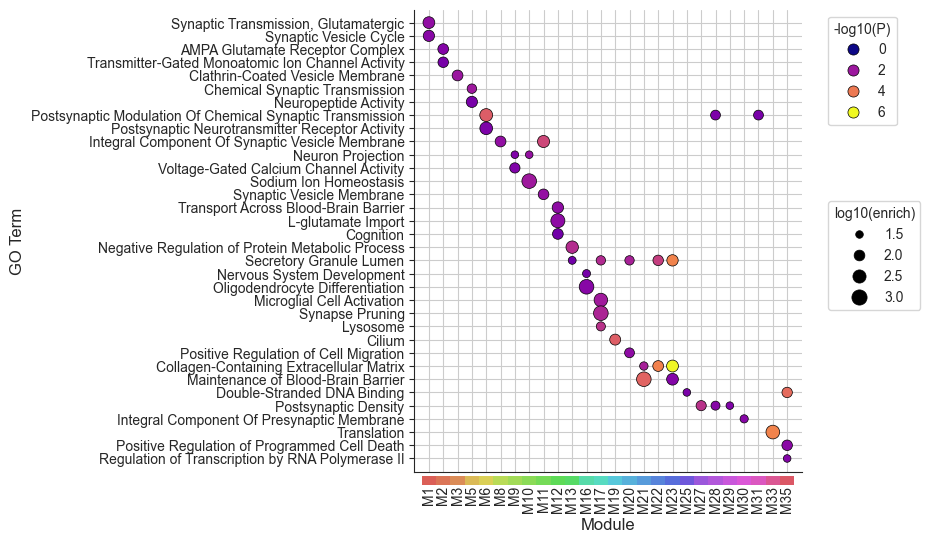

In [349]:
# Set up the figure
plt.figure(figsize=(5, 6))
sns.set_style("ticks")

# Create the bubble plot with continuous color mapping (keep your original data)
bubble_plot = sns.scatterplot(
    data=enrich_result_df,
    x='module_id',  
    y='Term',  
    size='log10(enrich)',
    hue='-log10(P)',
    palette='plasma',
    sizes=(30, 120),
    edgecolor='black',
    linewidth=0.5,
    hue_norm=(0, 6),
    size_norm=(1.5, 3),
)

plt.grid()
sns.despine()

# col colors 
# Fix the x-axis tick labels to match the actual number of columns
bubble_plot.tick_params(axis='x', which='major', pad=10, length=0) 

module_colors = sns.color_palette('hls', n_colors=len(top_genes_dict)).as_hex()
module_color_dict = dict(zip(top_genes_dict.keys(), module_colors))
module_to_plot = [module_color_dict[module] for module in enrich_result_df.module_id.unique()]
for i, color in enumerate(module_to_plot):
    bubble_plot.add_patch(plt.Rectangle(xy=(i-0.5, -0.03), width=1, height=.02, color=color, lw=0,
                               transform=bubble_plot.get_xaxis_transform(), clip_on=False))
    

# Remove the default legend
bubble_plot.legend_.remove()

# Create custom discrete color legend
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Define discrete levels for the legend
color_levels = [0, 2, 4, 6]
color_labels = ['0', '2', '4', '6']

# Get the colormap and normalization used in the plot
cmap = cm.get_cmap('plasma')
norm = Normalize(vmin=0, vmax=6)

# Create custom legend elements (colored dots)
color_legend_elements = []
for level, label in zip(color_levels, color_labels):
    color = cmap(norm(level))
    color_legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
               markersize=8, markeredgecolor='black', markeredgewidth=0.5,
               label=label)
    )

# Create size legend elements (get from original plot)
handles, labels = plt.gca().get_legend_handles_labels()
size_handles = []
size_labels = []

# Extract size information from the scatter collection
scatter = bubble_plot.collections[0]
sizes = scatter.get_sizes()
unique_sizes = sorted(list(set(sizes)))

# Create size legend with representative sizes
size_legend_elements = []
# size_values = [1.5, 2.0, 2.5, 3.0]  # Representative size values
# size_labels = ['1.5', '2.0', '2.5', '3.0']

size_values = [1.5, 2.0, 2.5, 3.0]  # Representative size values
size_labels = ['1.5', '2.0', '2.5', '3.0']

for size_val, size_label in zip(size_values, size_labels):
    # Calculate actual marker size (seaborn uses different scaling)
    marker_size = 30 + (size_val - 1.5) / (3.0 - 1.5) * (120 - 30)
    size_legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
               markersize=np.sqrt(marker_size), markeredgecolor='black', 
               markeredgewidth=0.5, label=size_label)
    )

# Add legends to the plot
color_legend = plt.legend(handles=color_legend_elements, 
                         title='-log10(P)', 
                         bbox_to_anchor=(1.05, 1), 
                         loc='upper left', 
                         fontsize=10,
                         frameon=True)

size_legend = plt.legend(handles=size_legend_elements, 
                        title='log10(enrich)', 
                        bbox_to_anchor=(1.05, 0.6), 
                        loc='upper left', 
                        fontsize=10,
                        frameon=True)

# Add the first legend back to the plot (matplotlib only shows the last legend by default)
plt.gca().add_artist(color_legend)

# Customize the plot
bubble_plot.set_xlabel('Module', fontsize=12)
bubble_plot.set_ylabel('GO Term', fontsize=12)
bubble_plot.set_xticklabels(bubble_plot.get_xticklabels(), rotation=90, fontsize=10)
bubble_plot.set_yticklabels(bubble_plot.get_yticklabels(), fontsize=10)
plt.margins(x=0.02, y=0.03)

plt.savefig(os.path.join(fig_path, f'cNMF_enrichr.pdf'), bbox_inches='tight', dpi=300)
plt.show()

### SCZ association

In [9]:
run_name = 'All_run'
n_genes = 50
current_output_path = os.path.join(nmf_output_path, run_name)

# load cNMF top genes 
top_genes = pd.read_csv(os.path.join(current_output_path, f'{run_name}_topgenes.csv'), index_col=0)
top_genes.columns = top_genes.columns.astype(str)
top_genes.columns = [module_name_dict[c] for c in top_genes.columns]
top_genes = top_genes.loc[:, natsorted(top_genes.columns)]
top_genes_dict = top_genes.head(n_genes).to_dict(orient='list')

In [10]:
gep_scores = pd.read_csv(os.path.join(current_output_path, f'{run_name}_gep_scores.csv'), index_col=0)
gep_scores.columns = gep_scores.columns.astype(str)
gep_scores.columns = [module_name_dict[c] for c in gep_scores.columns]
gep_scores = gep_scores.loc[:, natsorted(gep_scores.columns)]
gep_scores

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M26,M27,M28,M29,M30,M31,M32,M33,M34,M35
A2m,0.000006,0.000070,-0.000145,0.000106,0.000129,-0.000028,0.000059,0.000060,0.000156,-0.000013,...,-0.000094,-0.000296,0.000235,-0.000161,-0.000114,-0.000085,0.000053,-0.000220,-0.000103,-0.000205
A4galt,-0.000202,-0.000025,-0.000204,-0.000091,-0.000178,-0.000190,-0.000264,-0.000177,-0.000191,-0.000241,...,0.000714,-0.000375,-0.000035,-0.000296,-0.000156,-0.000105,-0.000217,-0.000057,-0.000159,-0.000021
Aacs,0.000442,-0.000060,-0.000143,-0.000099,-0.000147,-0.000142,-0.000128,-0.000123,0.000441,0.000598,...,-0.000051,-0.000430,-0.000254,-0.000114,-0.000091,-0.000154,0.000104,-0.000281,-0.000106,-0.000225
Aak1,0.001292,0.000276,0.000802,0.000096,0.000642,-0.000012,0.000125,-0.000073,0.000397,0.000145,...,-0.000211,-0.000226,0.000083,-0.000494,-0.000039,0.000511,0.000787,-0.000649,0.000058,-0.000802
Abca5,-0.000039,-0.000035,0.000305,0.000275,-0.000120,-0.000159,-0.000101,0.000137,-0.000035,0.000107,...,0.000041,-0.000426,0.000141,0.000248,0.000296,-0.000166,-0.000226,-0.000045,0.000188,-0.000142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Znrf1,0.000086,-0.000444,-0.000129,-0.000131,-0.000174,0.000371,0.000072,-0.000082,-0.000153,-0.000164,...,-0.000111,0.002384,-0.000175,-0.000174,0.000144,-0.000202,-0.000058,-0.000070,0.000215,-0.000504
Zswim6,-0.000217,-0.000043,0.000021,-0.000165,-0.000177,0.000564,0.000239,-0.000019,-0.000161,-0.000290,...,0.000054,-0.000546,-0.000167,0.000036,0.000405,-0.000070,-0.000141,-0.000347,0.000928,-0.000148
Zswim8,0.000231,-0.000049,-0.000066,-0.000099,-0.000120,-0.000189,0.000234,-0.000097,0.000005,0.000475,...,-0.000169,-0.000463,0.000691,-0.000205,0.000037,-0.000138,-0.000154,-0.000580,-0.000164,-0.000067
Zxdb,-0.000290,-0.000161,-0.000333,0.000067,-0.000089,0.000281,-0.000302,-0.000134,-0.000126,-0.000261,...,0.000360,0.001753,-0.000135,-0.000121,-0.000118,-0.000028,-0.000040,0.000073,-0.000150,-0.000236


In [11]:
usage_df = pd.read_csv(os.path.join(current_output_path, f'{run_name}_usage_norm.csv'), index_col=0)
usage_df.columns = usage_df.columns.str.split('_').str[1]
usage_df.columns = [module_name_dict[c] for c in usage_df.columns]
usage_df = usage_df.loc[:, natsorted(usage_df.columns)]

usage_df.head()

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M26,M27,M28,M29,M30,M31,M32,M33,M34,M35
unique_index,,,,,,,,,,,,,,,,,,,,,
sample8_Position688_1,0.000000,0.030429,0.000000,0.109197,0.012926,0.038250,0.0,0.000000,0.000000,0.000000,...,0.063449,0.000000,0.062486,0.008093,0.031324,0.079505,0.013661,0.030690,0.016116,0.000000
sample8_Position688_2,0.000000,0.007520,0.000000,0.000000,0.058934,0.071355,0.0,0.000000,0.000000,0.000000,...,0.018859,0.122697,0.000000,0.071732,0.074124,0.024739,0.000000,0.000000,0.000000,0.023701
sample8_Position688_3,0.007062,0.000000,0.020930,0.092126,0.000000,0.010882,0.0,0.000000,0.009625,0.000000,...,0.030461,0.056145,0.021319,0.000000,0.000000,0.070236,0.036888,0.007930,0.021668,0.000000
sample8_Position688_5,0.000000,0.010878,0.012413,0.085298,0.000000,0.000000,0.0,0.011352,0.051898,0.000000,...,0.033535,0.069382,0.000000,0.022602,0.088526,0.143542,0.000297,0.011969,0.000000,0.000000
sample8_Position688_6,0.000000,0.053767,0.036412,0.005109,0.000000,0.000000,0.0,0.045666,0.000000,0.009672,...,0.029551,0.028205,0.034066,0.012086,0.182894,0.210667,0.026152,0.013755,0.016983,0.009887


In [ ]:
# # get all unique values in top_genes_dict.values()
# top_genes_list = list(set(gene for module_genes in top_genes_dict.values() for gene in module_genes))
# sdata = adata[:, top_genes_list].copy()
# sdata

In [11]:
adata.X = adata.layers['raw'].copy()
sc.pp.normalize_total(adata, target_sum=1e3)
sc.pp.log1p(adata, base=2)
adata.layers['log2_norm1e3'] = adata.X.copy()

In [16]:
adata.X = adata.layers['log2_norm1e4_scaled'].copy()
score_columns = []

for module_name, module_genes in top_genes_dict.items():
    sc.tl.score_genes(adata, gene_list=module_genes, score_name=f'{module_name}_score')
    score_columns.append(f'{module_name}_score')


In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df_list = []
for current_protocol in ['STAR', 'RIBO']:
    for current_ctype in adata.obs['level_2'].cat.categories:
        current_df = adata.obs.loc[(adata.obs['protocol'] == current_protocol) & (adata.obs['level_2'] == current_ctype), score_columns + ['condition']]
        
        X = current_df.loc[:, score_columns].values
        y = current_df['condition'].values

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        rf = RandomForestClassifier(n_estimators=200, max_depth=None, max_features="sqrt", random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)

        # print(classification_report(y_test, y_pred))

        importances = rf.feature_importances_

        # Put into a nice dataframe
        current_importance_df = pd.DataFrame({
            "module": [i.split('_score')[0] for i in score_columns],
            "importance": importances,
            "protocol": current_protocol,
            "ctype": current_ctype
        }).sort_values(by="importance", ascending=False)
        df_list.append(current_importance_df)


importance_df = pd.concat(df_list)
importance_df

,module,importance,protocol,ctype
28,M29,0.053880,STAR,TEGLU
30,M31,0.031574,STAR,TEGLU
24,M25,0.031438,STAR,TEGLU
25,M26,0.031395,STAR,TEGLU
12,M13,0.030431,STAR,TEGLU
...,...,...,...,...
1,M2,0.024814,RIBO,Mix
19,M20,0.024643,RIBO,Mix
17,M18,0.024609,RIBO,Mix
16,M17,0.024485,RIBO,Mix


In [54]:
def change_width(ax, new_value) :
    for patch in ax.patches :
        current_width = patch.get_width()
        diff = current_width - new_value

        # we change the bar width
        patch.set_width(new_value)

        # we recenter the bar
        patch.set_x(patch.get_x() + diff * .5)

In [167]:
importance_df['protocol'] = importance_df['protocol'].astype('category')
importance_df['protocol'] = importance_df['protocol'].cat.reorder_categories(['STAR', 'RIBO'])

importance_df['module'] = importance_df['module'].astype('category')
importance_df['module'] = importance_df['module'].cat.reorder_categories([f"M{i}" for i in range(1, 36)])

importance_df['ctype'] = importance_df['ctype'].astype('category')
importance_df['ctype'] = importance_df['ctype'].cat.reorder_categories(adata.obs['level_2'].cat.categories)

importance_df = importance_df.loc[importance_df['ctype'] != 'Mix', :]

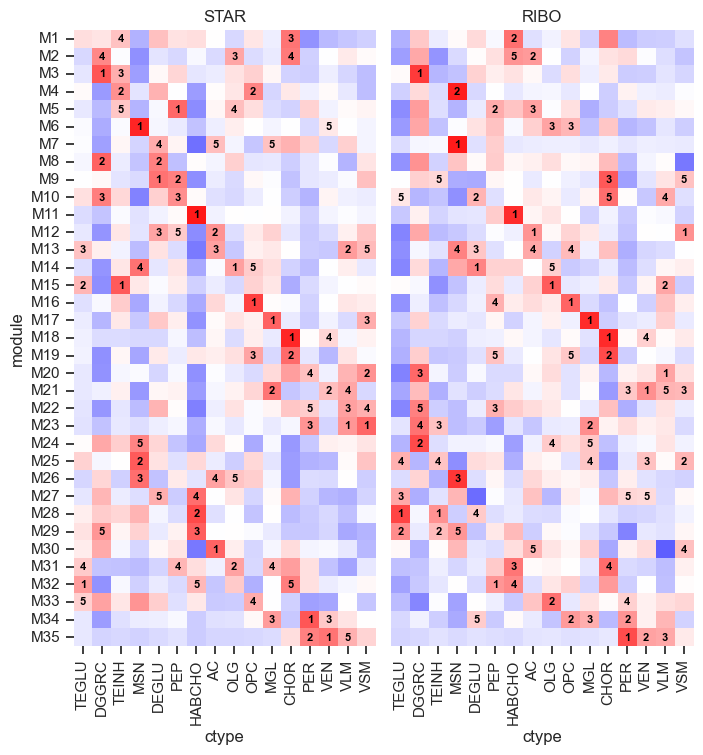

In [172]:
# Create data for both protocols
star_df = importance_df.loc[importance_df['protocol'] == 'STAR', :].pivot(index='module', columns='ctype', values='importance')
ribo_df = importance_df.loc[importance_df['protocol'] == 'RIBO', :].pivot(index='module', columns='ctype', values='importance')

# Calculate z-score for each column (cell type)
star_df_scaled = star_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
ribo_df_scaled = ribo_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(8, 8))      
gs  = GridSpec(
        nrows=1, ncols=2,  
        width_ratios =[.5, .5],
        hspace=0.05, wspace=0.05)

ax_star  = fig.add_subplot(gs[0, 0])      # left
ax_ribo = fig.add_subplot(gs[0, 1])      # right

# STAR heatmap on the left
sns.heatmap(star_df_scaled, cmap='bwr', ax=ax_star, vmin=-4, vmax=4, cbar=False)
ax_star.set_title('STAR')

# RIBO heatmap on the right
sns.heatmap(ribo_df_scaled, cmap='bwr', ax=ax_ribo, vmin=-4, vmax=4, cbar=False)
ax_ribo.set_title('RIBO')

ax_ribo.set_yticks([])               
ax_ribo.set_ylabel('')

# Annotate top 5 modules for each cell type on both heatmaps
for ctype_idx, ctype in enumerate(star_df_scaled.columns):
    # Get top 5 modules for STAR protocol
    star_top5 = star_df_scaled[ctype].nlargest(5)
    for rank, (module, importance) in enumerate(star_top5.items()):
        module_idx = star_df_scaled.index.get_loc(module)
        ax_star.text(ctype_idx + 0.5, module_idx + 0.5, str(rank + 1), 
                    ha='center', va='center', fontsize=8, fontweight='bold', color='black')
    
    # Get top 5 modules for RIBO protocol
    ribo_top5 = ribo_df_scaled[ctype].nlargest(5)
    for rank, (module, importance) in enumerate(ribo_top5.items()):
        module_idx = ribo_df_scaled.index.get_loc(module) 
        ax_ribo.text(ctype_idx + 0.5, module_idx + 0.5, str(rank + 1), 
                    ha='center', va='center', fontsize=8, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "module_importance_heatmap.pdf"), dpi=300)
plt.show()

## Clean output

In [5]:
nmf_output_path = os.path.join(output_path, 'nmf')
os.makedirs(nmf_output_path, exist_ok=True)

In [6]:
run_name = 'All_run'
n_genes = 50
current_output_path = os.path.join(nmf_output_path, run_name)

In [7]:
# load cNMF top genes 
top_genes = pd.read_csv(os.path.join(current_output_path, f'{run_name}_topgenes.csv'), index_col=0)
top_genes.columns = top_genes.columns.astype(str)
top_genes.columns = [module_name_dict[c] for c in top_genes.columns]
top_genes = top_genes.loc[:, natsorted(top_genes.columns)]
top_genes

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M26,M27,M28,M29,M30,M31,M32,M33,M34,M35
0,Atp1a1,Epha6,Pvalb,Rab3c,Npy,Ppp1r1b,Arpp21,Prkcd,Tcf7l2,Resp18,...,Sema3c,Shank1,Slc17a7,Gda,Trank1,Lamp5,Tmem178,Bcas1,Penk,Btg2
1,Rtn4r,Gabra5,Gad1,Oxr1,Sst,Rgs9,Baiap2,Pcp4,Kcnc2,Ly6h,...,Emid1,Camk2a,Pgm2l1,Rpl17,Snhg11,Nrgn,Tle4,Kif5b,Drd2,Dusp1
2,Bsn,Ppp3ca,Atp1b1,Peg3,Crhbp,Pde10a,Foxp1,Tnnt1,Rgs16,Scg2,...,Ctps,Map1a,Mapk1,Snca,Kctd16,Kcnh7,Sh3gl2,Mbp,Adora2a,Nr4a1
3,Chn1,Prkcg,Vamp1,Gprasp2,Gad2,Rasd2,Ano3,Pdp1,Ildr2,Dlk1,...,Sncg,Ppp1r9b,Wasf1,Trim2,Grin2b,Sema7a,Hs3st4,Rps12,Sim1,Junb
4,Rbfox3,Nr3c2,Slc6a1,Maged1,Pam,Pcp4,Phactr1,Rnf112,Ntng1,Nap1l5,...,Pdzrn3,Sptbn2,Nrgn,Rab6a,Gria3,Cux2,Nos1ap,Lpar1,Crb2,Fos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Ak5,Robo2,Ppm1l,Tmem160,Rgs17,Mchr1,Utrn,Ell2,Lrfn5,Kmt2a,...,Nppa,Mmd,Slitrk3,Ap3m2,Pxylp1,Coro6,Mapk10,Antxr1,Cited1,Chrm4
96,Plcxd2,Cyfip1,Scoc,Tmem240,Chl1,Ddit4l,Tac1,Ppm1k,Frmpd4,Gad2,...,Kmt2c,Rnf10,Ms4a15,Alcam,Elfn2,Rem2,Slc25a42,Hmgcs2,Wif1,Sstr2
97,Tmem178,Tacr3,Smim13,Wdfy3,Gna14,D430041d05rik,Drd2,Trim37,Vcpip1,Rnf34,...,Dcc,Ncor1,Hif1a,Kctd16,Scn2a,Dusp3,Slc8a2,Arhgap5,Gabra6,Txnip
98,Nfyc,Pcdhgc5,Hs3st1,Crtac1,Plekho1,Slc4a4,Kpna4,Kcnq3,Hdac9,Hmgcr,...,Tmem191c,Hcn2,Kalrn,Pdcd4,Anks1b,Hs2st1,Trib1,Agap1,Pou3f1,Hoxc5


In [15]:
# load cNMF usage norm
usage_norm = pd.read_csv(os.path.join(current_output_path, f'{run_name}_usage_norm.csv'), index_col=0)

# Rename columns to keep only the part after underscore
usage_norm.columns = [col.split('_')[-1] for col in usage_norm.columns]
usage_norm.columns = usage_norm.columns.astype(str)
usage_norm.columns = [module_name_dict[c] for c in usage_norm.columns]
usage_norm = usage_norm.loc[:, natsorted(usage_norm.columns)]
usage_norm

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M26,M27,M28,M29,M30,M31,M32,M33,M34,M35
unique_index,,,,,,,,,,,,,,,,,,,,,
sample8_Position688_1,0.000000,0.030429,0.000000,0.109197,0.012926,0.038250,0.000000,0.000000,0.000000,0.000000,...,0.063449,0.000000,0.062486,0.008093,0.031324,0.079505,0.013661,0.030690,0.016116,0.000000
sample8_Position688_2,0.000000,0.007520,0.000000,0.000000,0.058934,0.071355,0.000000,0.000000,0.000000,0.000000,...,0.018859,0.122697,0.000000,0.071732,0.074124,0.024739,0.000000,0.000000,0.000000,0.023701
sample8_Position688_3,0.007062,0.000000,0.020930,0.092126,0.000000,0.010882,0.000000,0.000000,0.009625,0.000000,...,0.030461,0.056145,0.021319,0.000000,0.000000,0.070236,0.036888,0.007930,0.021668,0.000000
sample8_Position688_5,0.000000,0.010878,0.012413,0.085298,0.000000,0.000000,0.000000,0.011352,0.051898,0.000000,...,0.033535,0.069382,0.000000,0.022602,0.088526,0.143542,0.000297,0.011969,0.000000,0.000000
sample8_Position688_6,0.000000,0.053767,0.036412,0.005109,0.000000,0.000000,0.000000,0.045666,0.000000,0.009672,...,0.029551,0.028205,0.034066,0.012086,0.182894,0.210667,0.026152,0.013755,0.016983,0.009887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample22_Position343_143,0.000000,0.066748,0.000000,0.000000,0.000000,0.000000,0.013270,0.000000,0.011981,0.063522,...,0.083104,0.000000,0.000000,0.284843,0.226217,0.042779,0.033765,0.010055,0.005598,0.002813
sample22_Position343_144,0.073404,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.022779,0.000000,...,0.299463,0.013437,0.000000,0.154936,0.037742,0.000000,0.000000,0.024484,0.000000,0.000000
sample22_Position343_145,0.000000,0.000000,0.004771,0.003554,0.002968,0.043532,0.016982,0.000000,0.004999,0.008313,...,0.068883,0.025756,0.013866,0.351671,0.157543,0.092778,0.029312,0.000000,0.012665,0.000000


In [ ]:
# load cNMF gep scores
gep_scores = pd.read_csv(os.path.join(current_output_path, f'{run_name}_gep_scores.csv'), index_col=0)
gep_scores.columns = gep_scores.columns.astype(str)
gep_scores.columns = [module_name_dict[c] for c in gep_scores.columns]
gep_scores = gep_scores.loc[:, natsorted(gep_scores.columns)]
gep_scores

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M26,M27,M28,M29,M30,M31,M32,M33,M34,M35
A2m,0.000006,0.000070,-0.000145,0.000106,0.000129,-0.000028,0.000059,0.000060,0.000156,-0.000013,...,-0.000094,-0.000296,0.000235,-0.000161,-0.000114,-0.000085,0.000053,-0.000220,-0.000103,-0.000205
A4galt,-0.000202,-0.000025,-0.000204,-0.000091,-0.000178,-0.000190,-0.000264,-0.000177,-0.000191,-0.000241,...,0.000714,-0.000375,-0.000035,-0.000296,-0.000156,-0.000105,-0.000217,-0.000057,-0.000159,-0.000021
Aacs,0.000442,-0.000060,-0.000143,-0.000099,-0.000147,-0.000142,-0.000128,-0.000123,0.000441,0.000598,...,-0.000051,-0.000430,-0.000254,-0.000114,-0.000091,-0.000154,0.000104,-0.000281,-0.000106,-0.000225
Aak1,0.001292,0.000276,0.000802,0.000096,0.000642,-0.000012,0.000125,-0.000073,0.000397,0.000145,...,-0.000211,-0.000226,0.000083,-0.000494,-0.000039,0.000511,0.000787,-0.000649,0.000058,-0.000802
Abca5,-0.000039,-0.000035,0.000305,0.000275,-0.000120,-0.000159,-0.000101,0.000137,-0.000035,0.000107,...,0.000041,-0.000426,0.000141,0.000248,0.000296,-0.000166,-0.000226,-0.000045,0.000188,-0.000142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Znrf1,0.000086,-0.000444,-0.000129,-0.000131,-0.000174,0.000371,0.000072,-0.000082,-0.000153,-0.000164,...,-0.000111,0.002384,-0.000175,-0.000174,0.000144,-0.000202,-0.000058,-0.000070,0.000215,-0.000504
Zswim6,-0.000217,-0.000043,0.000021,-0.000165,-0.000177,0.000564,0.000239,-0.000019,-0.000161,-0.000290,...,0.000054,-0.000546,-0.000167,0.000036,0.000405,-0.000070,-0.000141,-0.000347,0.000928,-0.000148
Zswim8,0.000231,-0.000049,-0.000066,-0.000099,-0.000120,-0.000189,0.000234,-0.000097,0.000005,0.000475,...,-0.000169,-0.000463,0.000691,-0.000205,0.000037,-0.000138,-0.000154,-0.000580,-0.000164,-0.000067
Zxdb,-0.000290,-0.000161,-0.000333,0.000067,-0.000089,0.000281,-0.000302,-0.000134,-0.000126,-0.000261,...,0.000360,0.001753,-0.000135,-0.000121,-0.000118,-0.000028,-0.000040,0.000073,-0.000150,-0.000236


In [18]:
# load cNMF gep tpm
gep_tpm = pd.read_csv(os.path.join(current_output_path, f'{run_name}_gep_tpm.csv'), index_col=0)
gep_tpm.columns = gep_tpm.columns.astype(str)
gep_tpm.columns = [module_name_dict[c] for c in gep_tpm.columns]
gep_tpm = gep_tpm.loc[:, natsorted(gep_tpm.columns)]
gep_tpm

,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,...,M26,M27,M28,M29,M30,M31,M32,M33,M34,M35
A2m,0.411788,0.608734,0.000000,0.686813,0.574578,0.106955,0.364638,0.813292,0.958848,0.289238,...,0.000000,0.000000,1.284460,0.000000,0.000000,0.000000,0.477996,0.000000,0.013186,0.000000
A4galt,0.000000,0.725569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.893193,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019085,0.000000,0.000000
Aacs,7.275151,0.000000,0.000000,0.000000,0.000000,0.000000,0.025473,0.000000,8.197992,9.286328,...,0.094309,0.000000,0.000000,0.000000,0.000000,0.000000,2.570657,0.120962,0.649827,0.000000
Aak1,27.829609,9.754051,21.765889,6.371963,15.539384,4.301381,6.172617,2.419825,11.957082,5.719390,...,0.000000,0.900485,8.023636,0.000000,4.243089,15.550788,21.554747,0.000000,4.277576,0.000000
Abca5,0.652501,0.336862,3.334661,3.766988,0.506931,0.000000,0.451075,2.627801,0.525914,1.809169,...,1.476200,0.000000,1.790449,2.714394,4.156451,0.000000,0.000000,0.355252,1.266488,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Znrf1,3.572903,0.000000,1.346119,0.277677,0.249262,10.933414,3.236101,0.776177,0.748891,1.229697,...,0.580567,26.466001,0.223361,0.068364,5.865868,0.289556,2.948539,2.733595,5.468464,0.000000
Zswim6,0.000000,0.357003,1.531817,0.000000,0.000000,8.496016,3.594559,1.579248,0.070207,0.000000,...,2.231411,0.000000,0.000000,1.517300,9.698705,0.491213,0.000000,0.000000,8.527980,1.355182
Zswim8,9.248518,0.000000,0.000000,0.000000,0.000000,0.000000,7.038308,0.000000,3.426721,13.736531,...,0.000000,0.000000,22.304060,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Zxdb,0.000000,2.374678,0.000000,9.689297,4.545808,13.772618,0.702213,2.200536,2.795851,0.898930,...,15.945181,28.640639,1.667948,2.991233,3.436733,6.676277,6.316690,5.348891,5.402591,1.829922


In [21]:
# Save to an excel file
with pd.ExcelWriter(os.path.join(output_path, f'cnmf_clean_output.xlsx')) as writer:
    usage_norm.to_excel(writer, sheet_name='usage_norm')
    gep_scores.to_excel(writer, sheet_name='gep_scores')
    gep_tpm.to_excel(writer, sheet_name='gep_tpm')
    top_genes.to_excel(writer, sheet_name='top_genes')
